#🛠️ Preparación de los Datos


##Extracción del Archivo Tratado

In [19]:
import pandas as pd

url = "https://raw.githubusercontent.com/Ari-aP/TelecomX_parte2_Latam/main/datos_tratados.csv"

df = pd.read_csv(url)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


##Eliminación de Columnas Irrelevantes

In [20]:
# eliminar columnas irrelevantes
df = df.drop(["customerID","Cuentas_Diarias"], axis=1)

# verificar
df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


##Encoding

In [21]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [22]:
df["Churn"] = df["Churn"].str.strip().map({"No": 0, "Yes": 1})
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()
df_encoded.columns

Index(['Churn', 'SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [23]:
#Separar variables para el modelo
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
X.shape
y.shape

(7032,)

In [24]:
#División de datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Verificación de la Proporción de Cancelación (Churn)

In [25]:
#cantidad de clientes por clase

Ejecuta:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [26]:
#proporción
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


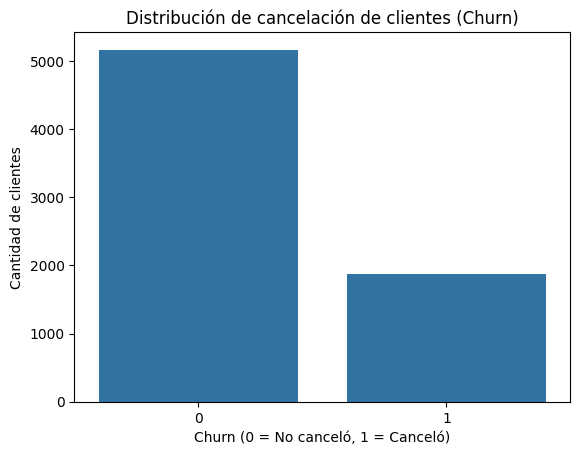

In [27]:
#gráfico
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)

plt.title("Distribución de cancelación de clientes (Churn)")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Cantidad de clientes")

plt.show()

El análisis de la variable Churn muestra que aproximadamente el 73% de los clientes continúan utilizando el servicio, mientras que cerca del 27% han cancelado su suscripción.

Esto indica que el dataset presenta un ligero desbalance entre las clases, lo cual es un aspecto importante a considerar durante el entrenamiento de los modelos predictivos, ya que puede influir en la capacidad del modelo para identificar correctamente los casos de cancelación.

##Balanceo de Clases

In [28]:
#balanceo con SMOTE
!pip install imbalanced-learn

In [29]:
#Aplicar SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [30]:
#Verificación del nuevo balance
import pandas as pd

pd.Series(y_resampled).value_counts()

,count
Churn,
0,5163
1,5163


Dado que el dataset presenta un desbalance moderado entre las clases de cancelación, se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) para equilibrar la distribución de la variable objetivo.

SMOTE genera ejemplos sintéticos de la clase minoritaria, permitiendo que el modelo aprenda mejor los patrones asociados a la cancelación de clientes y reduciendo el sesgo hacia la clase mayoritaria.

##Normalización o Estandarización

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
#Verificación de dimensiones
X_train_scaled.shape
X_test_scaled.shape

(1407, 30)

Dado que algunos algoritmos de Machine Learning, como la Regresión Logística, son sensibles a la escala de las variables, se aplicó estandarización mediante StandardScaler.

Este proceso transforma las variables para que tengan media 0 y desviación estándar 1, permitiendo que todas las características contribuyan de manera equilibrada durante el entrenamiento del modelo.

#🎯 Correlación y Selección de Variables

##Análisis de Correlación

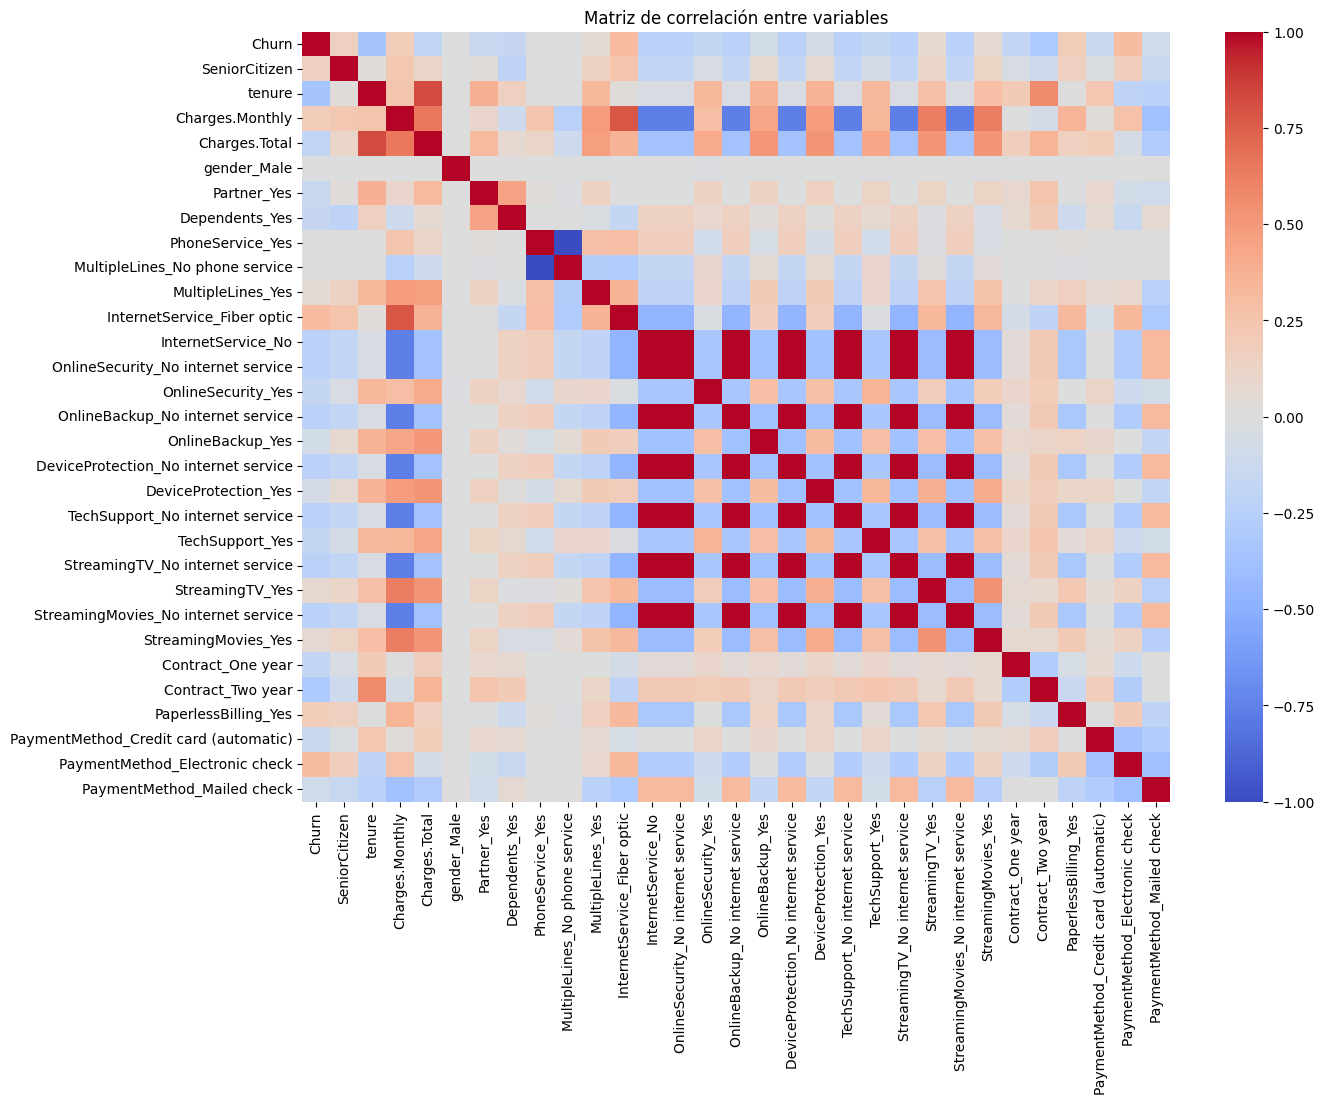

In [33]:
#Crear matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

corr = df_encoded.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación entre variables")
plt.show()

In [34]:
#Variables mas correlacionadas
corr["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
Charges.Monthly,0.192858
PaperlessBilling_Yes,0.191454
SeniorCitizen,0.150541
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860
MultipleLines_Yes,0.040033
PhoneService_Yes,0.011691


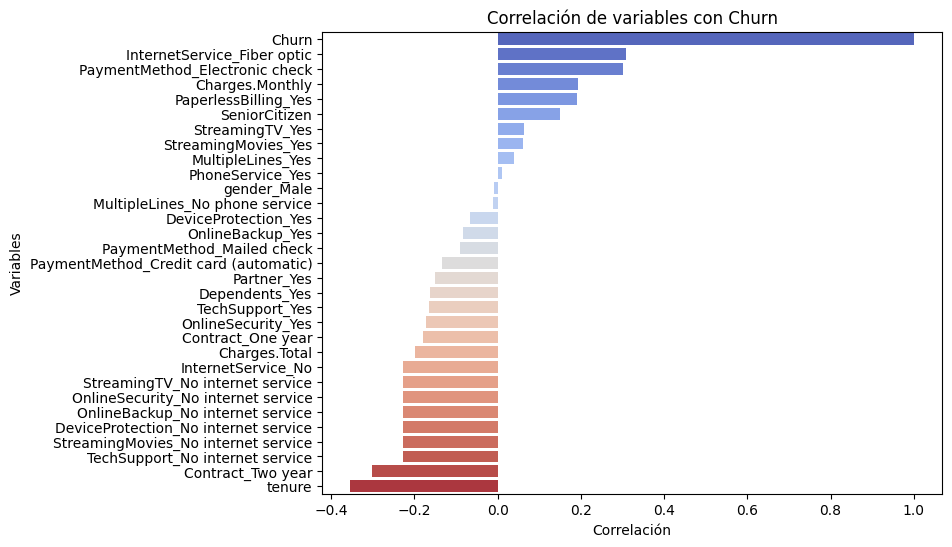

In [52]:
#Gráfico
plt.figure(figsize=(8,6))

corr_churn = corr["Churn"].sort_values(ascending=False)

sns.barplot(
    x=corr_churn.values,
    y=corr_churn.index,
    hue=corr_churn.index,
    palette="coolwarm",
    legend=False
)

plt.title("Correlación de variables con Churn")
plt.xlabel("Correlación")
plt.ylabel("Variables")

plt.show()

El análisis de correlación permite identificar qué variables están más relacionadas con la cancelación de clientes. Se observa que variables como contratos mensuales (Month-to-month) y el servicio de internet por fibra óptica presentan una correlación positiva con la cancelación.

Por otro lado, variables como tenure (tiempo de permanencia), contratos de dos años y cargos totales acumulados muestran correlaciones negativas, lo que sugiere que los clientes con mayor tiempo en la empresa o con contratos de largo plazo tienen menor probabilidad de cancelar el servicio.

##Análisis Dirigido

###Tiempo de contrato vs Cancelación (tenure vs Churn)

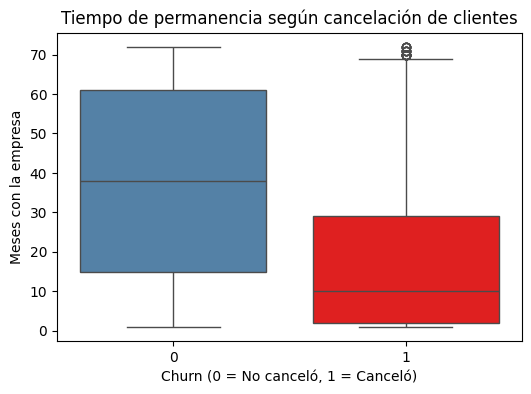

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df,
    hue="Churn",
    palette=["steelblue","red"],
    legend=False
)

plt.title("Tiempo de permanencia según cancelación de clientes")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Meses con la empresa")

plt.show()

El análisis muestra que los clientes que cancelan el servicio tienden a tener menor tiempo de permanencia en la empresa en comparación con aquellos que continúan utilizando el servicio. Esto sugiere que los clientes nuevos presentan mayor probabilidad de cancelar, lo que indica la importancia de estrategias de retención durante los primeros meses de relación con el cliente.

###Gasto total vs Cancelación (Charges.Total vs Churn)

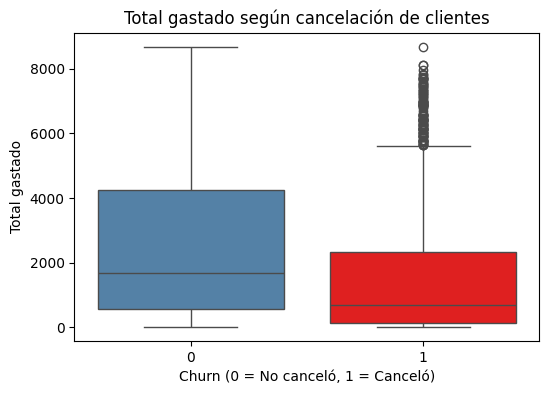

In [38]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="Charges.Total",
    data=df,
    hue="Churn",
    palette=["steelblue","red"],
    legend=False
)

plt.title("Total gastado según cancelación de clientes")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Total gastado")

plt.show()

Los clientes que permanecen en la empresa presentan, en promedio, un mayor gasto total acumulado, lo cual es consistente con su mayor tiempo de permanencia en el servicio. Por el contrario, los clientes que cancelan tienden a haber acumulado un menor gasto total, lo que sugiere que la cancelación ocurre con mayor frecuencia en etapas tempranas de la relación con el cliente.

###Gasto mensual vs Churn

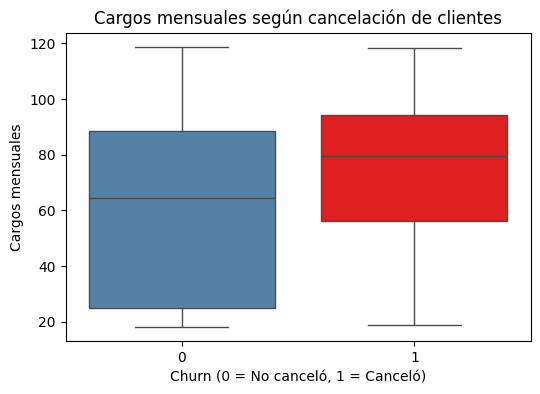

In [39]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="Charges.Monthly",
    data=df,
    hue="Churn",
    palette=["steelblue","red"],
    legend=False
)

plt.title("Cargos mensuales según cancelación de clientes")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Cargos mensuales")

plt.show()

Se observa que los clientes que cancelan tienden a presentar cargos mensuales ligeramente más altos, lo que podría indicar que precios elevados o planes más costosos pueden influir en la decisión de cancelar el servicio.

#🤖 Modelado Predictivo

##Separación de Datos

In [40]:
# Separar variables
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [41]:
#Dividir datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
#Verificar dimensiones
X_train.shape, X_test.shape

((5625, 30), (1407, 30))

Para evaluar el desempeño de los modelos predictivos, el conjunto de datos fue dividido en dos subconjuntos: 80% para entrenamiento y 20% para prueba.

Esta división permite entrenar el modelo con una parte de los datos y posteriormente evaluar su capacidad de generalización utilizando datos que no fueron utilizados durante el entrenamiento.

##Creación de Modelos

Se entrenaron dos modelos de clasificación para predecir la cancelación de clientes: Regresión Logística y Random Forest.

La Regresión Logística fue entrenada utilizando datos estandarizados, ya que este modelo es sensible a la escala de las variables. Por otro lado, Random Forest fue entrenado con los datos sin normalizar, dado que los modelos basados en árboles no dependen de la escala.

La comparación de métricas permite identificar cuál de los dos modelos presenta mejor desempeño para detectar clientes con riesgo de cancelación.

###Modelo 1: Regresión Logística

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

print("Accuracy - Regresión Logística:", accuracy_score(y_test, y_pred_lr))
print("\nReporte de clasificación - Regresión Logística")
print(classification_report(y_test, y_pred_lr))
print("\nMatriz de confusión - Regresión Logística")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy - Regresión Logística: 0.7960199004975125

Reporte de clasificación - Regresión Logística
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407


Matriz de confusión - Regresión Logística
[[918 115]
 [172 202]]


###Modelo 2: Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Accuracy - Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación - Random Forest")
print(classification_report(y_test, y_pred_rf))
print("\nMatriz de confusión - Random Forest")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy - Random Forest: 0.7768301350390903

Reporte de clasificación - Random Forest
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1033
           1       0.60      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407


Matriz de confusión - Random Forest
[[919 114]
 [200 174]]


##Evaluación de los Modelos

In [45]:
#Importar métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [46]:
#Evaluación — Regresión Logística
print("Evaluación - Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

print("\nMatriz de Confusión")
print(confusion_matrix(y_test, y_pred_lr))

Evaluación - Regresión Logística
Accuracy: 0.7960199004975125
Precision: 0.637223974763407
Recall: 0.5401069518716578
F1-score: 0.5846599131693199

Matriz de Confusión
[[918 115]
 [172 202]]


In [47]:
#Evaluación — Random Forest
print("Evaluación - Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nMatriz de Confusión")
print(confusion_matrix(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.7768301350390903
Precision: 0.6041666666666666
Recall: 0.46524064171123
F1-score: 0.525679758308157

Matriz de Confusión
[[919 114]
 [200 174]]


In [48]:
#Comparación de métricas
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.79602,0.637224,0.540107,0.58466
1,Random Forest,0.77683,0.604167,0.465241,0.52568


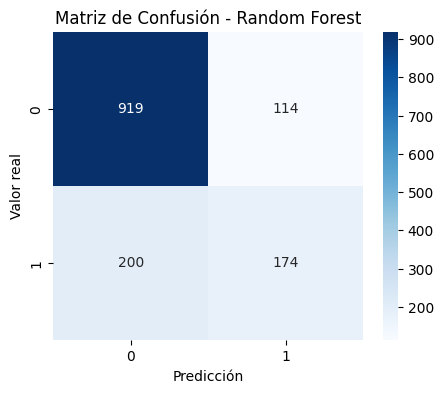

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

Se evaluaron dos modelos de clasificación para predecir la cancelación de clientes: Regresión Logística y Random Forest.

Los resultados muestran que la Regresión Logística obtuvo un mejor desempeño general, alcanzando una exactitud (accuracy) de aproximadamente 79.6%, superior al 77.7% obtenido por Random Forest.

Además, la Regresión Logística presentó mejores valores de precision, recall y F1-score, lo que indica una mayor capacidad para identificar correctamente a los clientes con riesgo de cancelación. En particular, el recall más alto sugiere que este modelo detecta un mayor número de clientes que efectivamente cancelan el servicio, lo cual es especialmente relevante para estrategias de retención.

En este contexto, la Regresión Logística se posiciona como el modelo más adecuado para este problema, ya que ofrece un mejor equilibrio entre precisión y capacidad de detección de cancelaciones.

#📋 Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

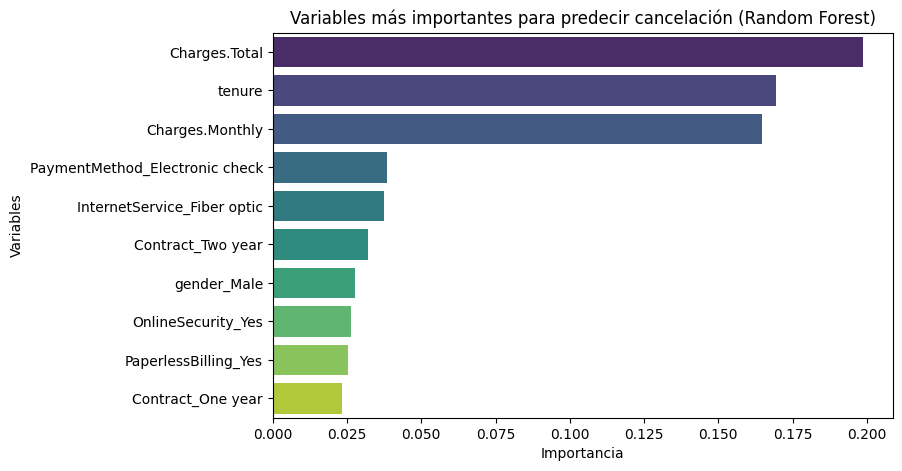

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_variables = importancias.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_variables.values,
    y=top_variables.index,
    hue=top_variables.index,
    palette="viridis",
    legend=False
)

plt.title("Variables más importantes para predecir cancelación (Random Forest)")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.show()

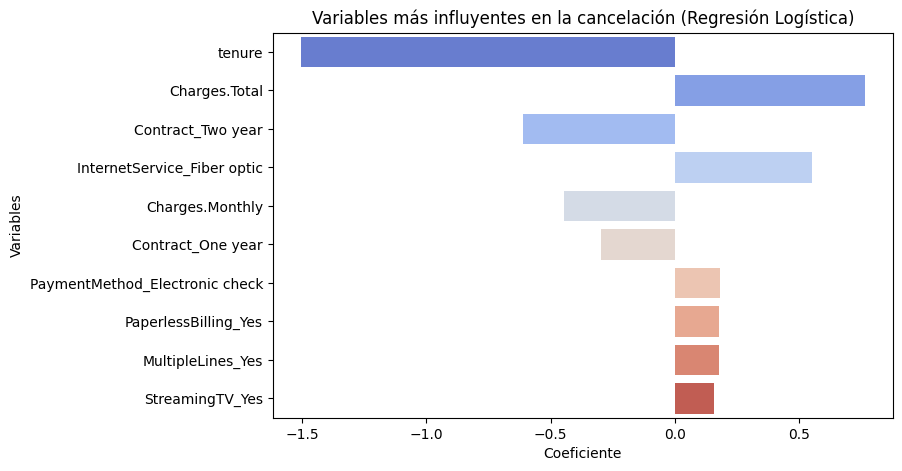

In [51]:
coeficientes = pd.Series(
    modelo_lr.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

top_coef = coeficientes.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_coef.values,
    y=top_coef.index,
    hue=top_coef.index,
    palette="coolwarm",
    legend=False
)

plt.title("Variables más influyentes en la cancelación (Regresión Logística)")
plt.xlabel("Coeficiente")
plt.ylabel("Variables")

plt.show()

###1. La permanencia del cliente es el factor más importante

Las variables tenure (tiempo con la empresa) y Charges.Total (gasto total acumulado) aparecen entre las más influyentes en ambos modelos.

Interpretación estratégica:

Los clientes que llevan más tiempo con la empresa tienen menor probabilidad de cancelar.

Esto sugiere que el riesgo de churn es mayor en los primeros meses de relación con el cliente.

Recomendación:

Telecom X debería implementar estrategias de retención temprana, por ejemplo:

programas de fidelización durante los primeros 6 meses

descuentos o beneficios para nuevos clientes

seguimiento proactivo a clientes recientes



###2. Los clientes con contratos mensuales tienen mayor riesgo de cancelación

Las variables relacionadas con tipo de contrato (Contract_One year, Contract_Two year) aparecen como relevantes.

Interpretación estratégica:

Los clientes con contratos más largos tienden a cancelar menos, mientras que los contratos mensuales presentan mayor rotación.

Recomendación:

Telecom X podría:

incentivar contratos de 1 o 2 años

ofrecer beneficios por permanencia

crear planes con descuento por compromiso de largo plazo

Esto puede reducir significativamente el churn.



###3. El costo del servicio influye en la cancelación

Las variables Charges.Monthly y Charges.Total aparecen entre las más influyentes.

Interpretación estratégica:

Los clientes con mayores cargos mensuales tienen mayor probabilidad de cancelar si perciben que el servicio no justifica el precio.

Recomendación:

La empresa debería:

revisar la estructura de precios

ofrecer planes personalizados

incluir beneficios adicionales en planes más costosos

Esto puede mejorar la percepción de valor del servicio.



###4. El tipo de servicio de internet también influye

La variable InternetService_Fiber optic aparece como importante.

Interpretación estratégica:

Esto puede indicar que algunos clientes con fibra óptica:

tienen mayores expectativas del servicio

o pagan más por el servicio

Si esas expectativas no se cumplen, aumenta el riesgo de cancelación.

Recomendación:

Telecom X debería:

mejorar la calidad del servicio de fibra

reforzar la atención al cliente en este segmento

monitorear la experiencia del usuario.


###5. Métodos de pago y facturación digital pueden influir

Variables como:

PaymentMethod_Electronic check

PaperlessBilling_Yes

también aparecen entre las más relevantes.

Interpretación estratégica:

Esto puede indicar que algunos métodos de pago están asociados a perfiles de clientes con mayor probabilidad de cancelación.

Recomendación:

La empresa podría:

analizar si ciertos métodos de pago están asociados a clientes menos fidelizados

promover métodos de pago más estables o automáticos

##Conclusión

A partir del análisis exploratorio de datos y la construcción de modelos predictivos, fue posible identificar los principales factores asociados a la cancelación de clientes (churn) en Telecom X.

Durante el proceso se realizaron etapas de limpieza, transformación y análisis de los datos, lo que permitió comprender mejor el comportamiento de los clientes y las variables que influyen en su decisión de cancelar el servicio. Posteriormente se entrenaron dos modelos de clasificación: Regresión Logística y Random Forest, con el objetivo de predecir la probabilidad de cancelación.

Los resultados mostraron que la Regresión Logística obtuvo el mejor desempeño general, alcanzando una exactitud cercana al 80%, además de presentar mejores valores de precision, recall y F1-score en comparación con Random Forest. Esto indica que este modelo tiene una mayor capacidad para identificar correctamente a los clientes con riesgo de cancelar el servicio.

El análisis de importancia de variables permitió identificar los factores que más influyen en la cancelación de clientes. Entre las variables más relevantes destacan:

Tiempo de permanencia del cliente (tenure)

Gasto total acumulado (Charges.Total)

Cargos mensuales del servicio (Charges.Monthly)

Tipo de contrato del cliente

Tipo de servicio de internet contratado

Los resultados indican que los clientes con menor tiempo de permanencia y aquellos con contratos mensuales presentan una mayor probabilidad de cancelar el servicio. Asimismo, los clientes con cargos mensuales más altos también muestran mayor riesgo de churn.)

##Recomendaciones

A partir de los hallazgos obtenidos, Telecom X podría implementar las siguientes estrategias para reducir la cancelación de clientes:

1. Fortalecer la retención de clientes nuevos
Dado que los clientes con menor tiempo en la empresa presentan mayor probabilidad de cancelar, es recomendable implementar programas de fidelización durante los primeros meses de servicio.

2. Incentivar contratos de mayor duración
Promover planes de 1 o 2 años con beneficios adicionales podría ayudar a reducir la cancelación asociada a contratos mensuales.

3. Revisar la estructura de precios y beneficios del servicio
Dado que los cargos mensuales influyen en la cancelación, Telecom X podría ofrecer planes más flexibles o beneficios adicionales para mejorar la percepción de valor del servicio.

4. Mejorar la experiencia del cliente en servicios clave
El tipo de servicio contratado también influye en la cancelación, por lo que mejorar la calidad del servicio y la atención al cliente puede contribuir a aumentar la satisfacción y reducir el churn.